Импортики, мои импортики

In [60]:
import matplotlib.pyplot as plt
#from sklearn.datasets import make_blobs
from sklearn import datasets

import random
from math import sqrt
from math import pow
import numpy as np

Константы

In [61]:

DIM_N = 2
POINT_N = 300
CLUST_N = 3
QU = 1.5 #степень размытия

Класс точки, используем только косвенно

In [62]:

class POINT:
    def __init__(self, cl, x, y):
        self.clust = cl
        self.X = x
        self.Y = y

класс кластера, непосредственно работаем с ним

In [63]:

class CLUSTER(POINT):
    def __init__(self, cl, x, y):
        POINT.__init__(self, cl, x, y)
        self.N = 0
    def Dist(self, p): #расчет дистанции до кластера, по формуле расстояния точки до точки
        return sqrt( (self.X - p.X)**2 + (self.Y - p.Y)**2 )
    def Eval_Center(self, P, M): #перерасчет центра кластера
        self.N = 0
        self.X = 0.0
        self.Y = 0.0 #обнуляем текущий центр
        a = 0.0
        for i in range(POINT_N):
            if P[i].clust == self.clust:  #проходимся по точкам этого кластера
                self.N += 1
                self.X += P[i].X*M[i][self.clust]  #умножаем на степень принадлежности из матрицы M
                self.Y += P[i].Y*M[i][self.clust]
                a = a + M[i][self.clust] # всего принадлежности этому кластеру (сумма принадлежностей?)
        if a != 0.0:
            self.X /= a
            self.Y /= a

Предобработная подготовка

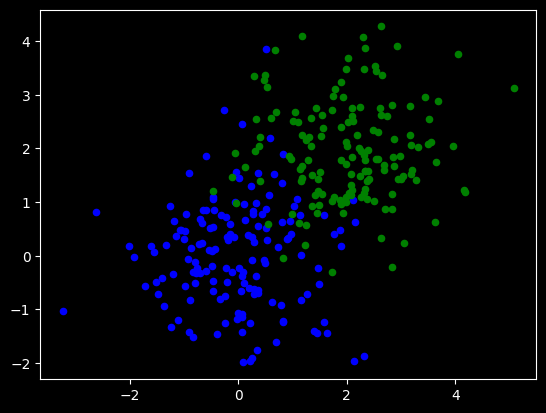

In [64]:

centers = [(0, 0), (2, 2)]
data, targ = datasets.make_blobs(n_samples=POINT_N, centers=centers, shuffle=False, random_state=42) #что-то библиотечное

for i in range(POINT_N):
        if targ[i] == 0:
            plt.scatter(data[i][0], data[i][1], c='blue', s=20)
        else:
            plt.scatter(data[i][0], data[i][1], c='green', s=20)
plt.show() #раскрасили
#рандомное объявление центров кластеров
Cl = [CLUSTER(0, 2.0*random.random()-1.0, 2.0*random.random()-1.0), CLUSTER(1, 2.0*random.random()-1.0, 2.0*random.random()-1.0)]
Cl = [CLUSTER(k, 2.0*random.random()-1.0, 2.0*random.random()-1.0) for k in range(CLUST_N)]
#Cl = [CLUSTER(0, 0, 0), CLUSTER(1, 2, 2)]

#список всех точек
PP = [POINT(CLUST_N, data[i,0], data[i,1]) for i in range(POINT_N)]

colors = plt.colormaps['tab10'].resampled(CLUST_N)



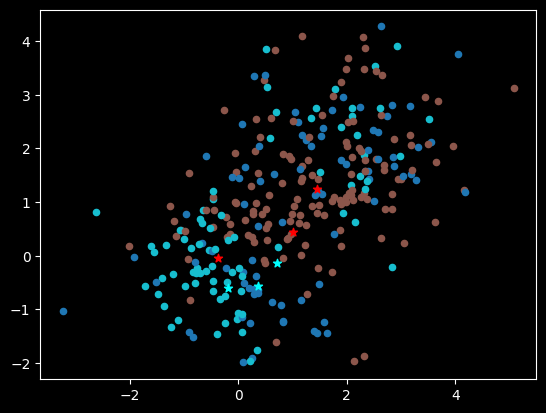

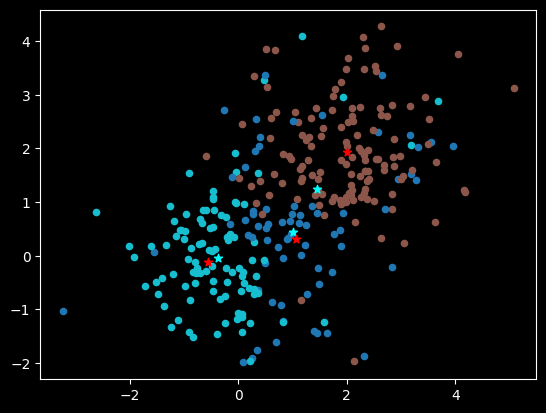

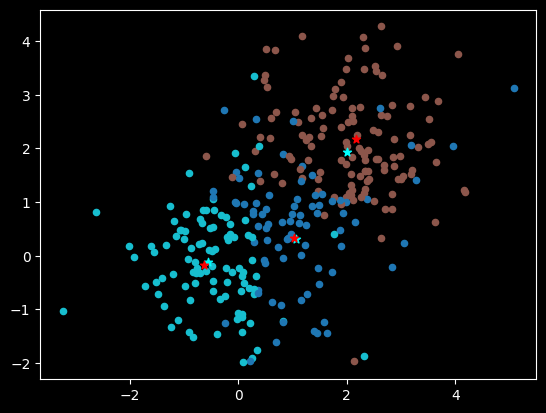

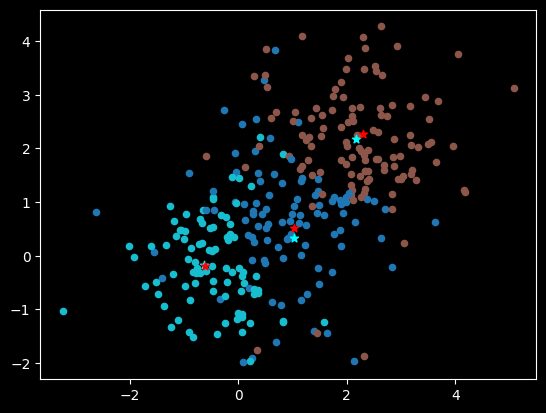

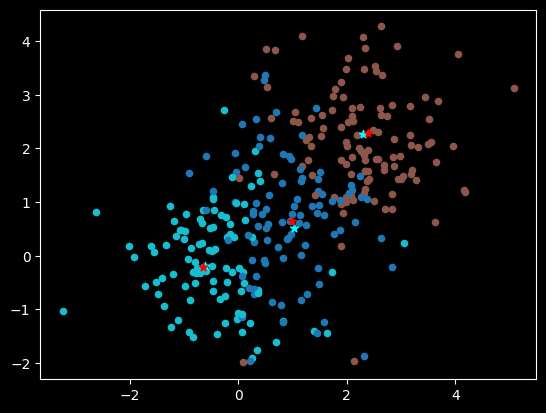

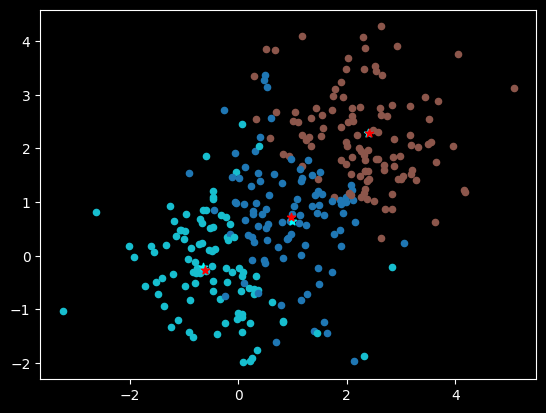

last ^^^


In [65]:

#крутимся, вертимся
while 1:
    #CC = [POINT(0, Cl[0].X, Cl[0].Y), POINT(1, Cl[1].X, Cl[1].Y)] #смотрим текущие центры кластеров
    CC = [POINT(k, Cl[k].X, Cl[k].Y) for k in range(CLUST_N)]
    Mu = [] #создаем новую матрицу принадлежности
    for i in range(POINT_N): #проход по всем точкам
        Mu.append([])

        a = 0.0
        for k in range(CLUST_N):
            Mu[i].append(1 / pow(Cl[k].Dist(PP[i]), 2/(QU-1))) #высчитываем принадлежность кластеру по страшной формуле
            a = a + Mu[i][k] #увеличиваем сумму принадлежности
        for k in range(CLUST_N):
            Mu[i][k] = Mu[i][k]/a #нормализация

    for i in range(POINT_N): #снова проходимся по всем точкам
        r = np.random.rand() #рандомно исходя из матрицы принадлежности запихиваем их в кластеры
        prob = 0.0
        for k in range(CLUST_N):
            prob += Mu[i][k]  # накапливаем вероятность
            if r < prob:
                PP[i].clust = k  # присваиваем кластер
                break

    for k in range(CLUST_N): #пересчитываем центры из рандома и матрицы
        Cl[k].Eval_Center(PP, Mu)

    for p in PP: #раскраска
        plt.scatter(p.X, p.Y, c=[colors(p.clust)], s=20)
    for cl in Cl:
            plt.scatter(CC[cl.clust].X, CC[cl.clust].Y, c='cyan', marker="*")
            plt.scatter(cl.X, cl.Y, c='red', marker="*")
    plt.show()

    max_shift = max(Cl[k].Dist(CC[k]) for k in range(CLUST_N))
    if max_shift < 0.1:
        print('last ^^^')
        break #останавливаемся если нас устраивает макс смещение




In [66]:
#то же самое, но для ирины фишерман
import pandas as pd

df = pd.read_csv('data/iris.csv')
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [67]:

data = df[['sepal.width', 'sepal.length']].values  # берем 2 признака
POINT_N = data.shape[0]

indices = np.random.choice(POINT_N, CLUST_N, replace=False)
Cl = [CLUSTER(k, data[idx][0], data[idx][1]) for k, idx in enumerate(indices)]
# список точек
PP = [POINT(CLUST_N, data[i][0], data[i][1]) for i in range(POINT_N)]

colors = plt.cm.get_cmap('tab10', CLUST_N)


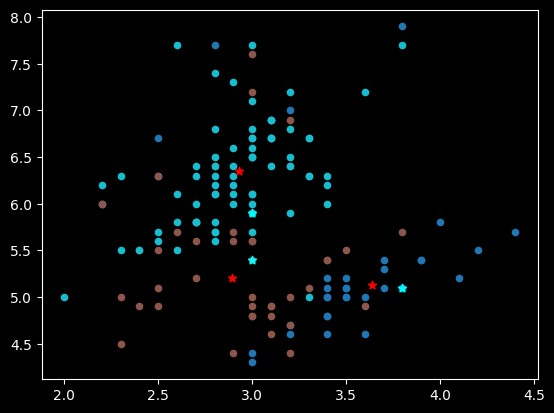

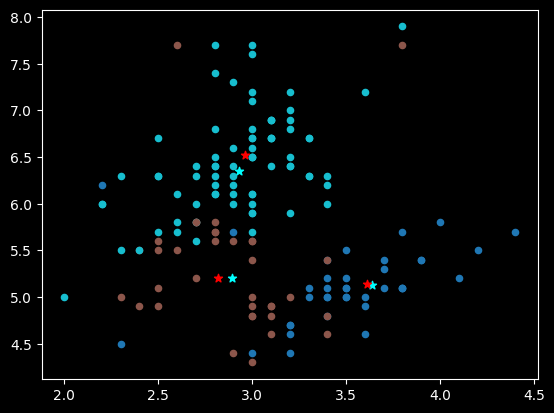

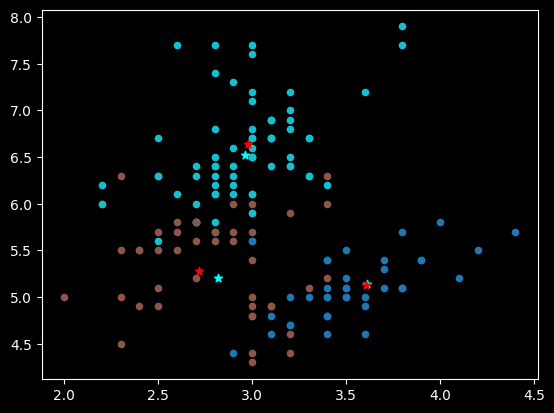

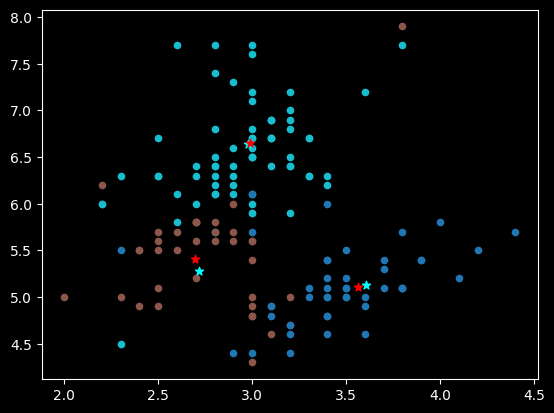

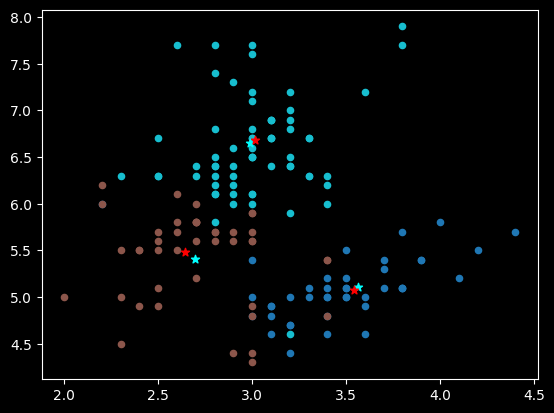

last ^^^


In [68]:
while 1:
    CC = [POINT(k, Cl[k].X, Cl[k].Y) for k in range(CLUST_N)] #смотрим текущие центры кластеров

    Mu = [] #создаем новую матрицу принадлежности
    for i in range(POINT_N): #проход по всем точкам
        Mu.append([])
        zero_idx = None
    # ищем совпадение с центром
        for k in range(CLUST_N):
            d = Cl[k].Dist(PP[i])
            if d == 0.0:
                zero_idx = k
                break
        if zero_idx is not None:
            # точка совпала с центром
            Mu[i] = [0.0]*CLUST_N
            Mu[i][zero_idx] = 1.0
            continue

        a = 0.0
        for k in range(CLUST_N):
            val = 1 / pow(Cl[k].Dist(PP[i]), 2/(QU-1))
            Mu[i].append(val)
            a += val

        for k in range(CLUST_N):
            Mu[i][k] /= a #нормализация

    for i in range(POINT_N): #снова проходимся по всем точкам
        r = np.random.rand() #рандомно исходя из матрицы принадлежности запихиваем их в кластеры
        prob = 0.0
        for k in range(CLUST_N):
            prob += Mu[i][k]  # накапливаем вероятность
            if r < prob:
                PP[i].clust = k  # присваиваем кластер
                break

    for k in range(CLUST_N): #пересчитываем центры из рандома и матрицы
        Cl[k].Eval_Center(PP, Mu)

    for p in PP: #раскраска
        plt.scatter(p.X, p.Y, c=[colors(p.clust)], s=20)
    for cl in Cl:
            plt.scatter(CC[cl.clust].X, CC[cl.clust].Y, c='cyan', marker="*")
            plt.scatter(cl.X, cl.Y, c='red', marker="*")
    plt.show()

    max_shift = max(Cl[k].Dist(CC[k]) for k in range(CLUST_N))
    if max_shift < 0.1:
        print('last ^^^')
        break